In [1]:
from galpy.potential import HernquistPotential
from tambora.dynamics import ExternalGalpyPotential
from WidrowKaiserFDM import WidrowKaiserFDM
import numpy as np, astropy.units as u
from galpy.potential import PlummerPotential, MovingObjectPotential, NullPotential
from galpy.orbit import Orbit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
from matplotlib.patches import Circle
from galpy.util.coords import rect_to_cyl, cyl_to_rect_vec

from astropy.constants import c

In [42]:
ro, vo = 8.0, 220.
a = 30.0 * u.kpc
M = 1e11 * u.Msun
targetPotential = HernquistPotential(amp=2*M, a=a, ro=ro*u.kpc, vo=vo*u.km/u.s)
targetPotential.turn_physical_on()

mboson = 1e-22 * u.eV / c**2
L = 31


In [ ]:
totalForce = WidrowKaiserFDM(targetPotential, mboson, L, update_freq = 0.5)
#fdmForce = totalForce - ExternalGalpyPotential(targetPotential)

Number of radial solutions for l = 0: 285
Number of radial solutions for l = 1: 284
Number of radial solutions for l = 2: 283
Number of radial solutions for l = 3: 282
Number of radial solutions for l = 4: 282
Number of radial solutions for l = 5: 281
Number of radial solutions for l = 6: 280
Number of radial solutions for l = 7: 280
Number of radial solutions for l = 8: 279
Number of radial solutions for l = 9: 278
Number of radial solutions for l = 10: 278
Number of radial solutions for l = 11: 277
Number of radial solutions for l = 12: 276
Number of radial solutions for l = 13: 276
Number of radial solutions for l = 14: 275
Number of radial solutions for l = 15: 275
Number of radial solutions for l = 16: 274
Number of radial solutions for l = 17: 273
Number of radial solutions for l = 18: 273
Number of radial solutions for l = 19: 272
Number of radial solutions for l = 20: 271
Number of radial solutions for l = 21: 271
Number of radial solutions for l = 22: 270
Number of radial solu

# Potential Field

In [30]:
# nx, ny = 21, 21
# buffer = 20
# x_20kpc = np.linspace(- buffer, buffer, nx)
# y_20kpc = np.linspace(-buffer, buffer, ny)
# X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
# pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

# net_acc_grid_20kpc = fdmForce.potential(pos_grid_20kpc, t=0.0)
# net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
# net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

# mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
# plt.figure(figsize=(8.5, 7))
# cmap = plt.cm.colors.ListedColormap(
#         plt.cm.Blues(np.linspace(0.2, 1.0, 256))
#     )
# cmap.set_bad('k')

# from matplotlib.colors import LogNorm
# norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
# pcm = plt.pcolormesh(
#     X_20kpc, Y_20kpc, mag_20kpc,
#     shading='auto',
#     cmap= cmap,
#     norm=norm
#     )
# plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')

# plt.xlabel("x [kpc]", fontsize=20)
# plt.ylabel("y [kpc]", fontsize=20)

# plt.tight_layout()
# plt.show()


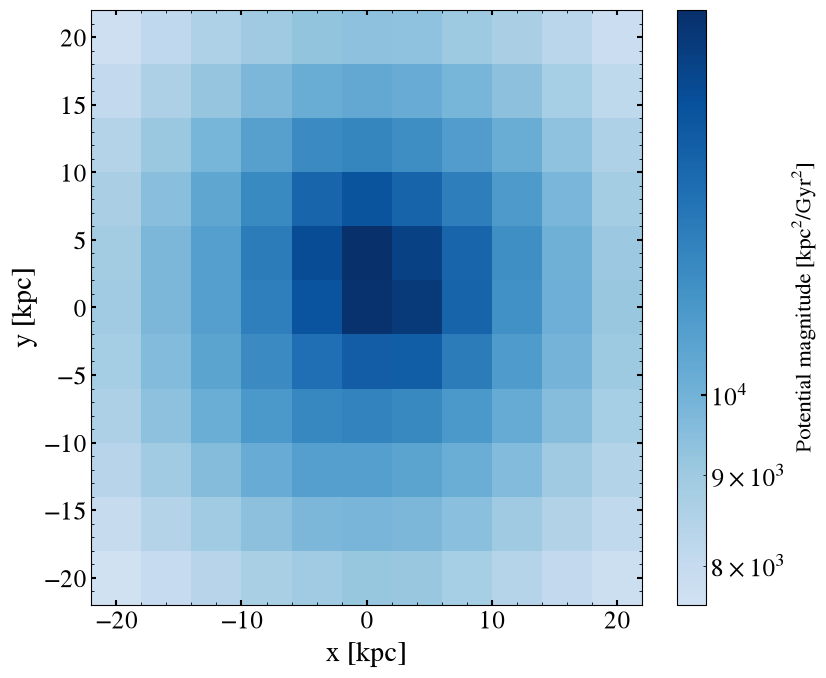

In [31]:
nx, ny = 11, 11
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

# potential() returns a scalar field of shape (N,), one value per position, so
# it must be reshaped onto the (ny, nx) grid before pcolormesh (unlike acc(),
# which is an (N, 3) vector). Plot |Phi| so the (negative) potential stays
# positive for LogNorm.
mag_20kpc = np.abs(
    np.asarray(totalForce.potential(pos_grid_20kpc, t=0.0)).reshape(X_20kpc.shape)
)

plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Potential magnitude [kpc$^2$/Gyr$^2$]')

plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.tight_layout()
plt.show()

In [32]:
totalForce.potential(pos_grid_20kpc, t=0.0)

array([ -7600.59712321,  -7988.44119996,  -8372.05128588,  -8718.16689911,
        -8979.81024931,  -9176.87888124,  -9123.2137116 ,  -8798.72825696,
        -8421.84996478,  -8081.60175201,  -7767.77362611,  -7972.67340757,
        -8446.09177719,  -8927.73758283,  -9417.75266915,  -9763.16486833,
        -9865.58377449,  -9749.8892043 ,  -9430.67194549,  -8986.27054025,
        -8523.49568804,  -8118.3542417 ,  -8361.77801489,  -8943.76356442,
        -9565.22764551, -10283.84288256, -10867.53888466, -10901.24078801,
       -10619.84823393, -10173.28149842,  -9601.38016379,  -9005.54659141,
        -8464.21273326,  -8648.0652241 ,  -9378.61793693, -10198.73808434,
       -11160.61608277, -11964.3994581 , -12136.5646248 , -11860.25461906,
       -11149.96851039, -10324.3258347 ,  -9526.706454  ,  -8798.05916271,
        -8830.5774029 ,  -9631.97614238, -10614.65040607, -11780.85383236,
       -13031.93441915, -13913.46052237, -13870.37647464, -12445.97395131,
       -11023.505782  ,  

# Acceleration Field

In [33]:
# nx, ny = 21, 21
# buffer = 20
# x_20kpc = np.linspace(- buffer, buffer, nx)
# y_20kpc = np.linspace(-buffer, buffer, ny)
# X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
# pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

# net_acc_grid_20kpc = fdmForce.acc(pos_grid_20kpc, t=0.0)
# net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
# net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

# mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
# plt.figure(figsize=(8.5, 7))
# cmap = plt.cm.colors.ListedColormap(
#         plt.cm.Blues(np.linspace(0.2, 1.0, 256))
#     )
# cmap.set_bad('k')

# from matplotlib.colors import LogNorm
# norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
# pcm = plt.pcolormesh(
#     X_20kpc, Y_20kpc, mag_20kpc,
#     shading='auto',
#     cmap= cmap,
#     norm=norm
#     )
# plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')
# plt.xlabel("x [kpc]", fontsize=20)
# plt.ylabel("y [kpc]", fontsize=20)

# plt.tight_layout()
# plt.show()


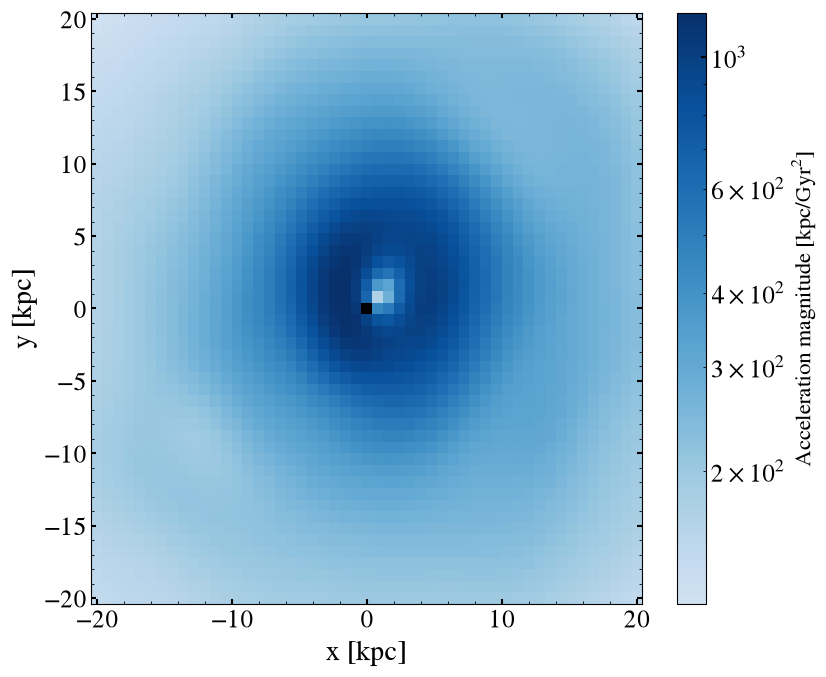

In [41]:
nx, ny = 51, 51
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

net_acc_grid_20kpc = totalForce.acc(pos_grid_20kpc, t=3.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)

plt.tight_layout()
plt.show()

# Animations

Time-evolution of the four colormaps above. Each animation sweeps the field
over `anim_times` (Gyr) and shares a fixed color scale across frames.

In [35]:
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm
from IPython.display import HTML


# def animate_colormap(field_fn, times, label='Acceleration magnitude [kpc/Gyr$^2$]',
#                      nx=21, ny=21, buffer=20, interval=200):
#     """Animate the in-plane magnitude of a field over time.

#     ``field_fn(pos_grid, t=...)`` must return an (N, >=2) array; columns 0 and 1
#     are combined in quadrature to form the plotted magnitude. Returns an HTML
#     (jshtml) animation for inline display in the notebook.
#     """
#     x = np.linspace(-buffer, buffer, nx)
#     y = np.linspace(-buffer, buffer, ny)
#     X, Y = np.meshgrid(x, y)
#     pos_grid = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])

#     # Pre-compute every frame and a shared (time-independent) color scale.
#     frames = []
#     for t in times:
#         net = field_fn(pos_grid, t=t)
#         U = net[:, 0].reshape(X.shape)
#         V = net[:, 1].reshape(Y.shape)
#         frames.append(np.hypot(U, V))
#     vmin = min(np.nanmin(f) for f in frames)
#     vmax = max(np.nanmax(f) for f in frames)

#     cmap = plt.cm.colors.ListedColormap(plt.cm.Blues(np.linspace(0.2, 1.0, 256)))
#     cmap.set_bad('k')
#     norm = LogNorm(vmin=vmin, vmax=vmax)

#     fig, ax = plt.subplots(figsize=(8.5, 7))
#     pcm = ax.pcolormesh(X, Y, frames[0], shading='auto', cmap=cmap, norm=norm)
#     fig.colorbar(pcm, ax=ax, label=label)
#     ax.set_xlabel("x [kpc]", fontsize=20)
#     ax.set_ylabel("y [kpc]", fontsize=20)
#     title = ax.set_title(f"t = {times[0]:.2f} Gyr")
#     fig.tight_layout()

#     def update(i):
#         pcm.set_array(frames[i].ravel())
#         title.set_text(f"t = {times[i]:.2f} Gyr")
#         return pcm, title

#     anim = FuncAnimation(fig, update, frames=len(times), interval=interval, blit=False)
#     plt.close(fig)  # avoid showing a static duplicate of the first frame
#     return HTML(anim.to_jshtml())


# # Time samples shared by the animations below (Gyr); adjust range/resolution as needed.
# anim_times = np.linspace(0.0, 2.0, 21)
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm
from IPython.display import HTML


def animate_colormap(field_fn, times, label='Field magnitude',
                     nx=51, ny=51, buffer=20, interval=200):
    """Animate the magnitude of a field over time.

    ``field_fn(pos_grid, t=...)`` may return either an (N, >=2) vector field
    (e.g. acc(), whose columns 0 and 1 are combined in quadrature) or an (N,)
    scalar field (e.g. potential(), whose absolute value is taken). Returns an
    HTML (jshtml) animation for inline display in the notebook.
    """
    x = np.linspace(-buffer, buffer, nx)
    y = np.linspace(-buffer, buffer, ny)
    X, Y = np.meshgrid(x, y)
    pos_grid = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])

    def _magnitude(net):
        net = np.asarray(net)
        if net.ndim == 1 or net.shape[-1] == 1:  # scalar field (e.g. potential)
            return np.abs(net.reshape(X.shape))
        U = net[:, 0].reshape(X.shape)           # vector field (e.g. acc)
        V = net[:, 1].reshape(X.shape)
        return np.hypot(U, V)

    # Pre-compute every frame and a shared (time-independent) color scale.
    frames = [_magnitude(field_fn(pos_grid, t=t)) for t in times]
    vmin = min(np.nanmin(f) for f in frames)
    vmax = max(np.nanmax(f) for f in frames)

    cmap = plt.cm.colors.ListedColormap(plt.cm.Blues(np.linspace(0.2, 1.0, 256)))
    cmap.set_bad('k')
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8.5, 7))
    pcm = ax.pcolormesh(X, Y, frames[0], shading='auto', cmap=cmap, norm=norm)
    fig.colorbar(pcm, ax=ax, label=label)
    ax.set_xlabel("x [kpc]", fontsize=20)
    ax.set_ylabel("y [kpc]", fontsize=20)
    title = ax.set_title(f"t = {times[0]:.2f} Gyr")
    fig.tight_layout()

    def update(i):
        pcm.set_array(frames[i].ravel())
        title.set_text(f"t = {times[i]:.2f} Gyr")
        return pcm, title

    anim = FuncAnimation(fig, update, frames=len(times), interval=interval, blit=False)
    plt.close(fig)  # avoid showing a static duplicate of the first frame
    return HTML(anim.to_jshtml())


# Time samples shared by the animations below (Gyr); adjust range/resolution as needed.
anim_times = np.linspace(0.0, 2.0, 21)

In [36]:
# Animated potential field — FDM force only
# animate_colormap(fdmForce.potential, anim_times)

In [37]:
# Animated potential field — total force (FDM + target)
#animate_colormap(totalForce.potential, anim_times)

In [38]:
# Animated acceleration field — FDM force only
# animate_colormap(fdmForce.acc, anim_times)

In [39]:
# Animated acceleration field — total force (FDM + target)
animate_colormap(totalForce.acc, anim_times)

KeyboardInterrupt: 